In [ ]:
# Colab の場合はまずランタイムを GPU に変更してから実行

# Install the latest compatible versions of the libraries to avoid conflicts.
# The --upgrade flag ensures we get recent versions.
!pip install --quiet --upgrade diffusers transformers accelerate safetensors huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.7 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

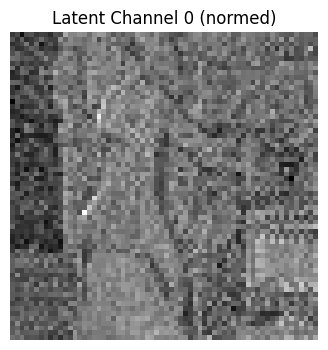

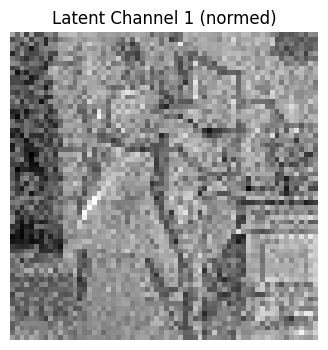

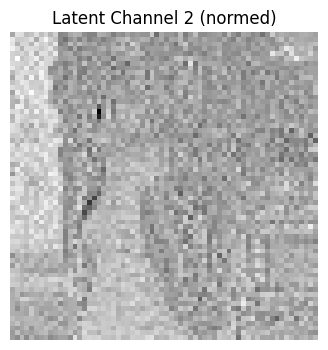

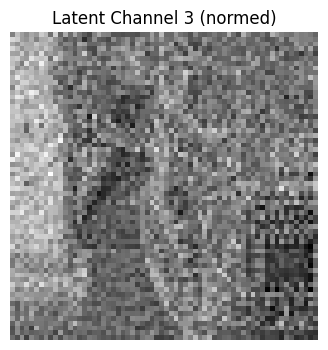

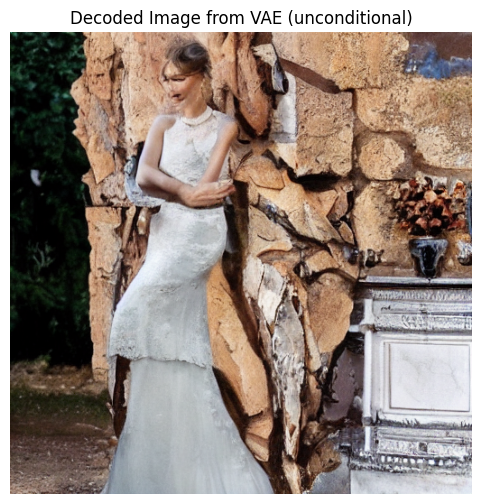

In [1]:
# =============================================================================
# Stable Diffusion VAE ― Unconditional Generation Latent ➜ Decoded Image
# =============================================================================
import torch, random, numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# ---------------------------------------------------------------------
# 0. 再現性の完全固定
# ---------------------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# torch.cuda.manual_seed_all(SEED) # Use torch.manual_seed for the generator instead

# ---------------------------------------------------------------------
# 1. Pipeline 読み込み（fp16, GPU）
#    * VAE・UNet など一式を読み込みます（≈4 GB）。
# ---------------------------------------------------------------------
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
).to("cuda")
pipe.set_progress_bar_config(disable=True)  # Colab のログを簡素化

# ---------------------------------------------------------------------
# 2. 「プロンプトなし」で 1 枚生成し，最終 latent を取得
#    output_type="latent" にすると decode をスキップし，(4, 64, 64) Tensor が得られる
# ---------------------------------------------------------------------
with torch.autocast("cuda"):
    # For reproducibility, create a generator and seed it.
    gen = torch.Generator(device="cuda").manual_seed(SEED)
    latent_out = pipe(
        prompt              = "",               # unconditional
        num_inference_steps = 50,
        output_type         = "latent",
        generator           = gen,
    ).images[0]        # Tensor, shape [4, 64, 64], dtype=float16, device=cuda

# ---------------------------------------------------------------------
# 3. VAE デコーダへ入力し，RGB 画像 (3, 512, 512) を取得
#    * Stable Diffusion では latent / scaling_factor (=0.18215) が標準
# ---------------------------------------------------------------------
# The scaling_factor is part of the VAE's configuration
scaling_factor = pipe.vae.config.scaling_factor
with torch.no_grad():
    # Add a batch dimension, scale, and decode
    decoded = pipe.vae.decode(latent_out.unsqueeze(0) / scaling_factor).sample
# Clamp and normalize the image to the [0, 1] range for visualization
decoded = (decoded.clamp(-1, 1) + 1) / 2
decoded = decoded.squeeze(0).cpu().float()

# ---------------------------------------------------------------------
# 4. 可視化（subplot を避け，各 Figure は単独）
# ---------------------------------------------------------------------
# 4-A) latent tensor の各チャネル（Grayscale）
for ch in range(4):
    plt.figure(figsize=(4, 4))
    img = latent_out[ch].cpu().float()
    img_min, img_max = img.min(), img.max()
    # Normalize to 0-1 range for visualization
    img_norm = (img - img_min) / (img_max - img_min + 1e-8)
    plt.imshow(img_norm, cmap="gray")
    plt.title(f"Latent Channel {ch} (normed)")
    plt.axis("off")
    plt.show()

# 4-B) デコーダ出力画像
plt.figure(figsize=(6, 6))
plt.imshow(decoded.permute(1, 2, 0).numpy())
plt.title("Decoded Image from VAE (unconditional)")
plt.axis("off")
plt.show()